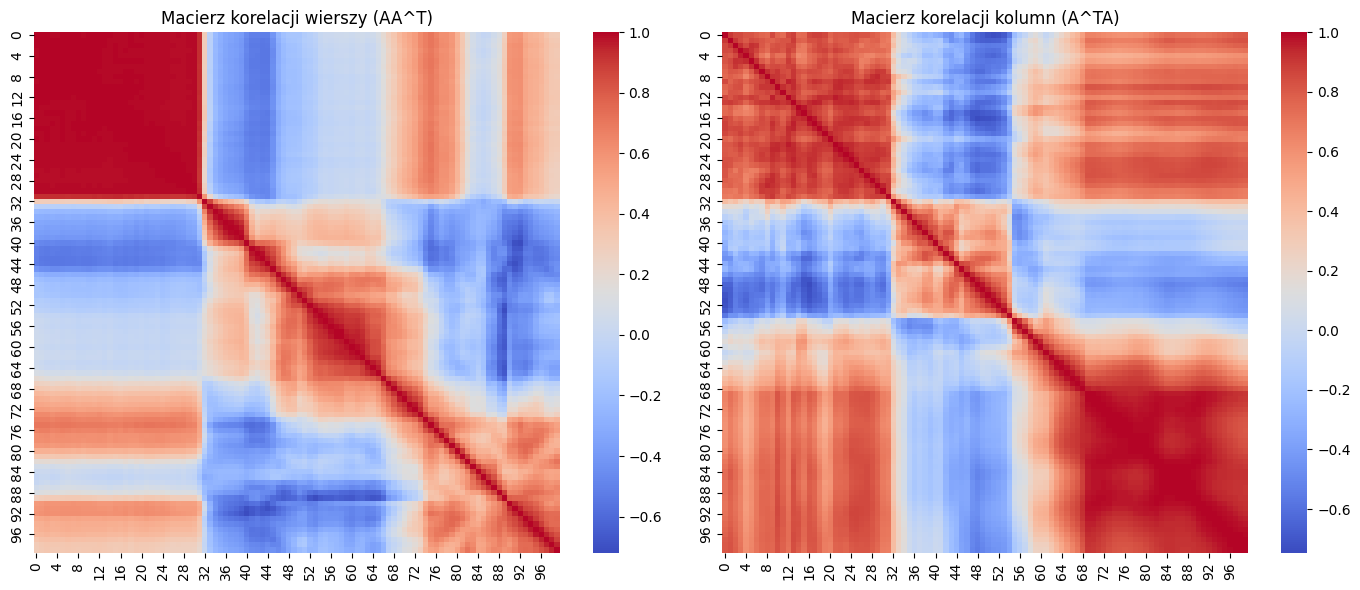

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# --- KONFIGURACJA ŚCIEŻKI ---
# Upewnij się, że ta ścieżka prowadzi do Twojego folderu
folder_path = '/content/drive/MyDrive/Folder'
file_name = '1.webp'
full_path = os.path.join(folder_path, file_name)

# Sprawdzenie czy plik istnieje
if not os.path.exists(full_path):
    print(f"BŁĄD: Nie znaleziono pliku pod ścieżką: {full_path}")
    print("Sprawdź, czy uruchomiłeś 'drive.mount' i czy nazwa folderu jest poprawna.")
else:
    # 1. Wczytanie obrazu
    img = Image.open(full_path).convert('L')
    # Opcjonalnie: pomniejszenie obrazu, żeby macierz korelacji była czytelna
    img = img.resize((100, 100))
    A = np.array(img, dtype=float)

    # 2. Obliczenie macierzy korelacji
    df = pd.DataFrame(A)
    corr_rows = df.T.corr()  # Korelacja wierszy
    corr_cols = df.corr()    # Korelacja kolumn

    # 3. Wizualizacja
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.heatmap(corr_rows, cmap='coolwarm', cbar=True)
    plt.title("Macierz korelacji wierszy (AA^T)")

    plt.subplot(1, 2, 2)
    sns.heatmap(corr_cols, cmap='coolwarm', cbar=True)
    plt.title("Macierz korelacji kolumn (A^TA)")

    plt.tight_layout()
    plt.show()